# Capstone Project — Artist Classification
## Best Artworks of All Time
**Tuwaiq Academy | ML, Deep Learning & NLP Applications**

---
## Step 0 — Install and Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
import kagglehub

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

print('All libraries imported!')
print('TensorFlow version:', tf.__version__)

All libraries imported!
TensorFlow version: 2.20.0


---
# Step 1 — Machine Learning Models (Weeks 1-4)
## Task 1.1 — Load and Explore the Data

In [ ]:
path = kagglehub.dataset_download("ikarus777/best-artworks-of-all-time")
print("Dataset downloaded to:", path)
data_path = os.path.join(path, "images", "images")
df = pd.read_csv(os.path.join(path, "artists.csv"))
print(df.head())

100%|██████████| 2.29G/2.29G [00:20<00:00, 119MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/ikarus777/best-artworks-of-all-time/versions/1
   id                name        years                         genre  \
0   0   Amedeo Modigliani  1884 - 1920                 Expressionism   
1   1  Vasiliy Kandinskiy  1866 - 1944  Expressionism,Abstractionism   
2   2        Diego Rivera  1886 - 1957       Social Realism,Muralism   
3   3        Claude Monet  1840 - 1926                 Impressionism   
4   4       Rene Magritte  1898 - 1967      Surrealism,Impressionism   

  nationality                                                bio  \
0     Italian  Amedeo Clemente Modigliani (Italian pronunciat...   
1     Russian  Wassily Wassilyevich Kandinsky (Russian: Васи́...   
2     Mexican  Diego María de la Concepción Juan Nepomuceno E...   
3      French  Oscar-Claude Monet (; French: [klod mɔnɛ]; 14 ...   
4     Belgian  René François Ghislain Magritte (French: [ʁəne...   

                                        wikipedia  paint

In [ ]:
# Check the shape (rows and columns)
print('Shape:', df.shape)
print('Number of rows   :', df.shape[0])
print('Number of columns:', df.shape[1])

Shape: (50, 8)
Number of rows   : 50
Number of columns: 8


In [ ]:
# Check for missing values
print('Missing values in each column:')
print(df.isnull().sum())

# Fill missing values with 'Unknown'
df = df.fillna('Unknown')
print('\nAfter filling missing values:')
print(df.isnull().sum())

Missing values in each column:
id             0
name           0
years          0
genre          0
nationality    0
bio            0
wikipedia      0
paintings      0
dtype: int64

After filling missing values:
id             0
name           0
years          0
genre          0
nationality    0
bio            0
wikipedia      0
paintings      0
dtype: int64


In [ ]:
images_folder = os.path.join(path, "images", "images")

artist_image_count = {}

for artist_name in os.listdir(images_folder):
    folder_path = os.path.join(images_folder, artist_name)
    if os.path.isdir(folder_path):
        image_files = [f for f in os.listdir(folder_path)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        artist_image_count[artist_name] = len(image_files)


artist_image_count = dict(
    sorted(artist_image_count.items(), key=lambda x: x[1], reverse=True)
)

print(f"إجمالي الفنانين: {len(artist_image_count)}")
for artist, count in list(artist_image_count.items())[:10]:
    print(f"  {artist}: {count} صورة")


إجمالي الفنانين: 51
  Vincent_van_Gogh: 877 صورة
  Edgar_Degas: 702 صورة
  Pablo_Picasso: 439 صورة
  Pierre-Auguste_Renoir: 336 صورة
  Albrecht_Du╠êrer: 328 صورة
  Albrecht_DuΓòá├¬rer: 328 صورة
  Paul_Gauguin: 311 صورة
  Francisco_Goya: 291 صورة
  Rembrandt: 262 صورة
  Alfred_Sisley: 259 صورة


In [ ]:
# Pick the top 5 artists (more images = better for training)
top_artists = list(artist_image_count.keys())[:5]
print('Top 5 artists we will use:')
for i, artist in enumerate(top_artists):
    print(f'  {i+1}. {artist} — {artist_image_count[artist]} images')

Top 5 artists we will use:
  1. Vincent_van_Gogh — 877 images
  2. Edgar_Degas — 702 images
  3. Pablo_Picasso — 439 images
  4. Pierre-Auguste_Renoir — 336 images
  5. Albrecht_Du╠êrer — 328 images


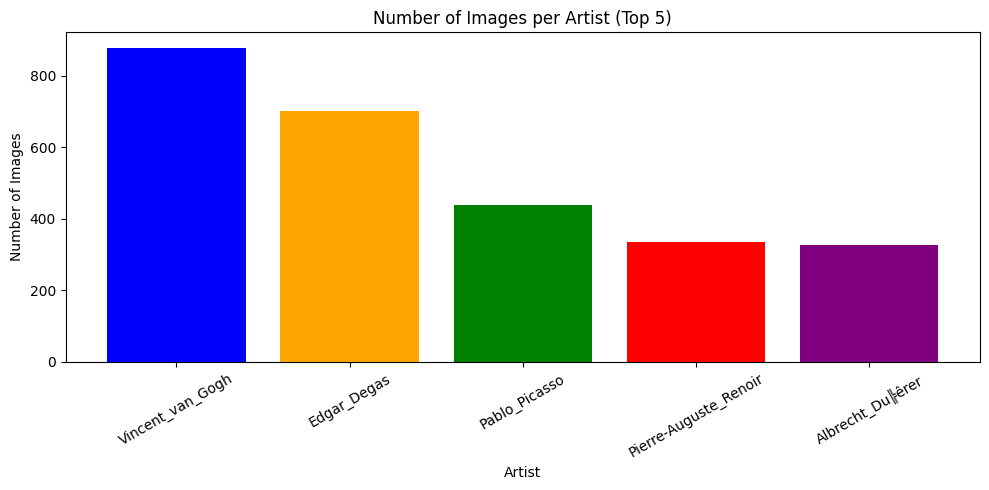

Note: Classes are not perfectly balanced.
We will use F1-score as our main metric because of this imbalance.


In [ ]:
# Check class balance — bar chart
counts = [artist_image_count[a] for a in top_artists]

plt.figure(figsize=(10, 5))
plt.bar(top_artists, counts, color=['blue', 'orange', 'green', 'red', 'purple'])
plt.title('Number of Images per Artist (Top 5)')
plt.xlabel('Artist')
plt.ylabel('Number of Images')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('class_balance.png')
plt.show()

print('Note: Classes are not perfectly balanced.')
print('We will use F1-score as our main metric because of this imbalance.')

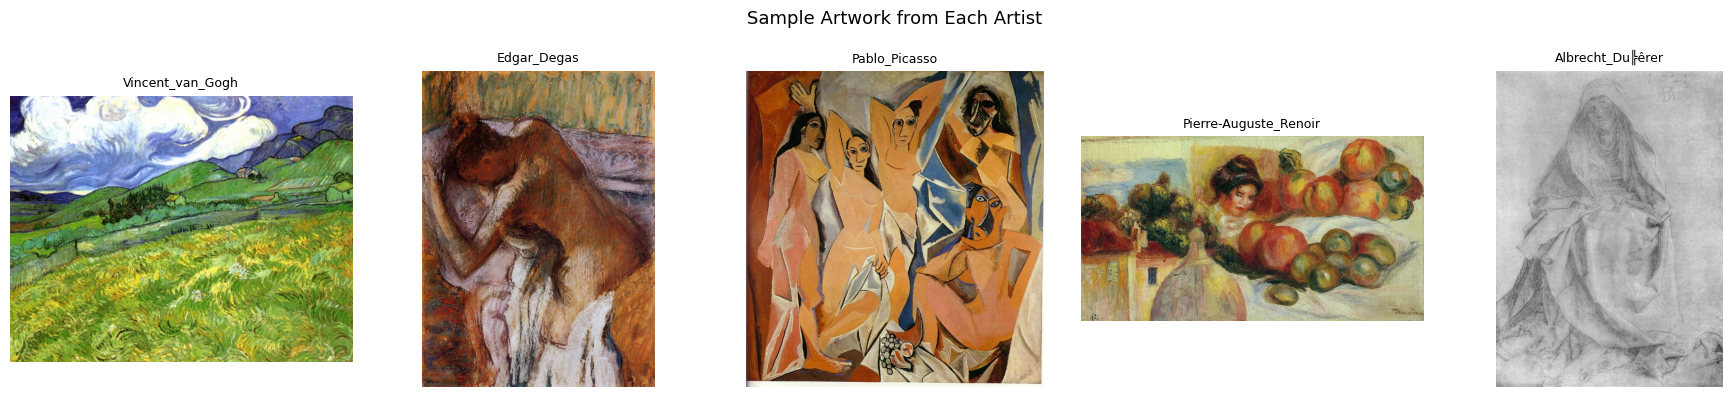

In [ ]:
# Show one sample image from each artist
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, artist in enumerate(top_artists):
    folder_path = os.path.join(images_folder, artist)
    first_image = os.listdir(folder_path)[0]
    img_path    = os.path.join(folder_path, first_image)
    img         = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(artist, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Artwork from Each Artist', fontsize=13)
plt.tight_layout()
plt.savefig('sample_images.png')
plt.show()

## Task 1.2 — Prepare the Data

In [ ]:
IMG_SIZE       = 64
IMG_SIZE_NN    = 224
MAX_PER_ARTIST = 60

X      = []
X_img  = []
y      = []

for artist_folder in top_artists:
    folder_path = os.path.join(images_folder, artist_folder)
    image_files = [f for f in os.listdir(folder_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    image_files = image_files[:MAX_PER_ARTIST]

    for img_file in image_files:
        img_path = os.path.join(folder_path, img_file)
        try:
            img = Image.open(img_path).convert('RGB')


            img_small = img.resize((IMG_SIZE, IMG_SIZE))
            X.append(np.array(img_small).flatten() / 255.0)


            img_big = img.resize((IMG_SIZE_NN, IMG_SIZE_NN))
            X_img.append(np.array(img_big) / 255.0)

            y.append(artist_folder)
        except:
            pass

X     = np.array(X)
X_img = np.array(X_img)
y     = np.array(y)

print('X shape (ML):', X.shape)
print('X_img shape (NN):', X_img.shape)
print('y shape:', y.shape)


X shape (ML): (300, 12288)
X_img shape (NN): (300, 224, 224, 3)
y shape: (300,)


In [ ]:
# Convert artist names to numbers
# For example: 'Van_Gogh' -> 3
le        = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Label encoding:')
for i, name in enumerate(le.classes_):
    print(f'  {i} = {name}')

Label encoding:
  0 = Albrecht_Du╠êrer
  1 = Edgar_Degas
  2 = Pablo_Picasso
  3 = Pierre-Auguste_Renoir
  4 = Vincent_van_Gogh


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)
Xi_train, Xi_test, _, _ = train_test_split(
    X_img,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print('Training samples :', len(X_train))
print('Testing samples  :', len(X_test))

print('Training samples  :', len(X_train))
print('Testing  samples  :', len(X_test))


Training samples : 240
Testing samples  : 60
Training samples  : 240
Testing  samples  : 60


## Task 1.3 — Train and Compare 3 Models

In [ ]:
# Helper function: train model and print results
def train_and_evaluate(model_name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print('------------------------------------------')
    print('Model    :', model_name)
    print('Accuracy :', round(acc,  4))
    print('Precision:', round(prec, 4))
    print('Recall   :', round(rec,  4))
    print('F1-Score :', round(f1,   4))

    return {
        'Model': model_name,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1-Score' : round(f1,   4),
        'preds'    : y_pred
    }

all_results = []

In [ ]:
# Model 1: Logistic Regression
lr     = LogisticRegression(max_iter=500, random_state=42)
res_lr = train_and_evaluate('Logistic Regression', lr)
all_results.append(res_lr)

------------------------------------------
Model    : Logistic Regression
Accuracy : 0.4
Precision: 0.3883
Recall   : 0.4
F1-Score : 0.3807


In [ ]:
# Model 2: Random Forest
rf     = RandomForestClassifier(n_estimators=100, random_state=42)
res_rf = train_and_evaluate('Random Forest', rf)
all_results.append(res_rf)

------------------------------------------
Model    : Random Forest
Accuracy : 0.4333
Precision: 0.4221
Recall   : 0.4333
F1-Score : 0.419


In [ ]:
# Model 3: KNN
knn     = KNeighborsClassifier(n_neighbors=5)
res_knn = train_and_evaluate('KNN (k=5)', knn)
all_results.append(res_knn)

------------------------------------------
Model    : KNN (k=5)
Accuracy : 0.4
Precision: 0.4021
Recall   : 0.4
F1-Score : 0.3661


In [ ]:
# Summary table
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'preds'}
    for r in all_results
])

print('===== STEP 1 SUMMARY TABLE =====')
print(summary.to_string(index=False))

best = summary.loc[summary['F1-Score'].idxmax(), 'Model']
print(f'\nBest model: {best}')
print('Reason: highest F1-Score. We use F1-Score because the classes are not perfectly balanced.')


===== STEP 1 SUMMARY TABLE =====
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.4000     0.3883  0.4000    0.3807
      Random Forest    0.4333     0.4221  0.4333    0.4190
          KNN (k=5)    0.4000     0.4021  0.4000    0.3661

Best model: Random Forest
Reason: highest F1-Score. We use F1-Score because the classes are not perfectly balanced.


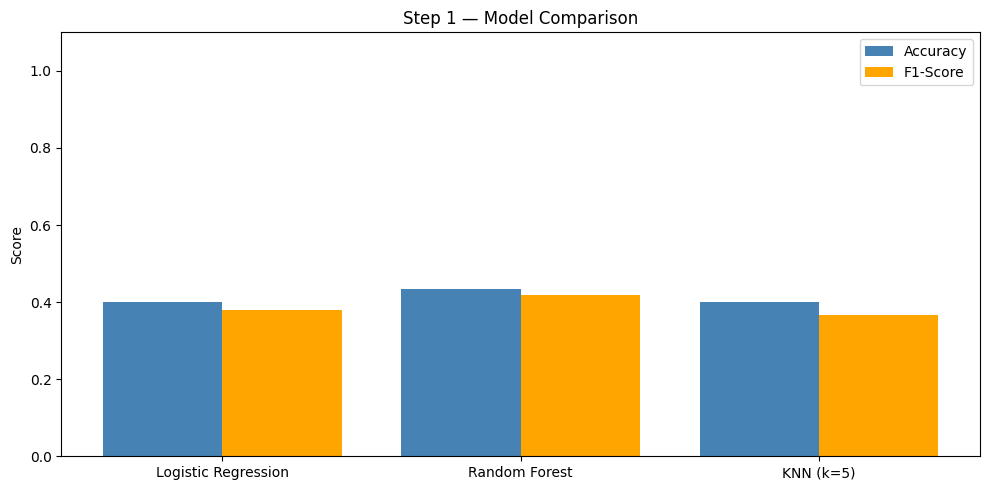

In [ ]:
# Comparison bar chart
model_names = [r['Model']    for r in all_results]
f1_scores   = [r['F1-Score'] for r in all_results]
accuracies  = [r['Accuracy'] for r in all_results]

x = range(len(model_names))

plt.figure(figsize=(10, 5))
plt.bar([i - 0.2 for i in x], accuracies, width=0.4, label='Accuracy', color='steelblue')
plt.bar([i + 0.2 for i in x], f1_scores,  width=0.4, label='F1-Score', color='orange')
plt.xticks(x, model_names)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Step 1 — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

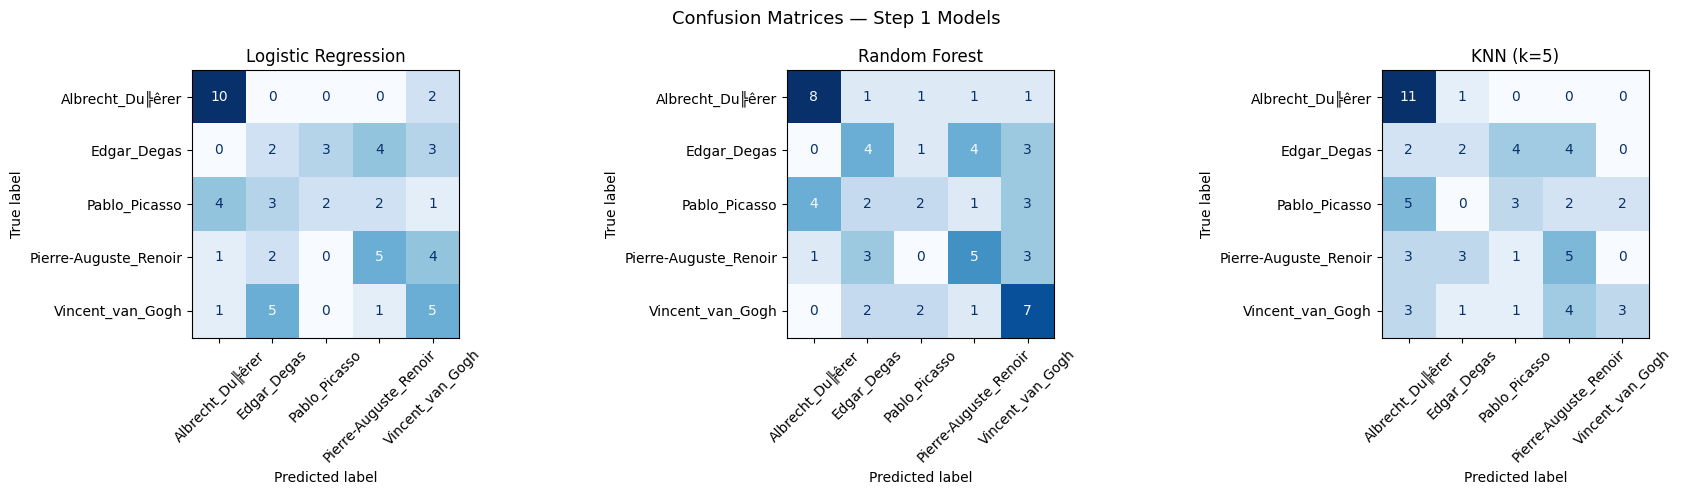

In [ ]:
# Confusion matrix for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, result in enumerate(all_results):
    cm   = confusion_matrix(y_test, result['preds'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, xticks_rotation=45)
    axes[i].set_title(result['Model'])

plt.suptitle('Confusion Matrices — Step 1 Models', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

---
# Step 2 — Neural Network (Weeks 5-8)
## Task 2.1 — Build and Train

In [ ]:
# How many artists (output classes) do we have?
num_classes = len(le.classes_)
print('Number of classes  :', num_classes)
print('Number of features :', X_train.shape[1])

Number of classes  : 5
Number of features : 12288


In [ ]:
# Convert labels to one-hot encoding
y_train_ohe = to_categorical(y_train, num_classes)
y_test_ohe  = to_categorical(y_test,  num_classes)

print('y_train_ohe shape:', y_train_ohe.shape)
print('Example row:', y_train_ohe[0])


y_train_ohe shape: (240, 5)
Example row: [1. 0. 0. 0. 0.]


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input


base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)


base_model.trainable = False

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
], name="data_augmentation")

nn_model = keras.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])
nn_model.build((None, 224, 224, 3))
nn_model.summary()
print(f'\nTrainable params: {nn_model.count_params():,}')


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,792 (16.70 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)


Trainable params: 4,378,792


In [ ]:

nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('Phase 1 compiled — training head only')


Phase 1 compiled — training head only


In [ ]:
early_stop_1 = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr_1 = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print('Callbacks جاهزة!')


Callbacks جاهزة!


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

Xi_train_pre = preprocess_input(Xi_train * 255)
Xi_test_pre  = preprocess_input(Xi_test * 255)

# =============== Phase 1: Head Training ===============
print('=== Phase 1: Training head only ===')
history1 = nn_model.fit(
    Xi_train_pre, y_train_ohe,
    validation_split=0.2,
    epochs=20,
    batch_size=16,
    shuffle=True,
    callbacks=[early_stop_1, reduce_lr_1]
)

# =============== Phase 2: Fine-tuning ===============
print('\n=== Phase 2: Fine-tuning last 60 layers ===')


base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False


nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_2 = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

history2 = nn_model.fit(
    Xi_train_pre, y_train_ohe,
    validation_split=0.2,
    epochs=30,
    batch_size=16,
    shuffle=True,
    callbacks=[early_stop_2]
)


import collections
history_combined = collections.defaultdict(list)
common_keys = set(history1.history.keys()) & set(history2.history.keys())
for key in common_keys:
    history_combined[key] = history1.history[key] + history2.history[key]

print('\nTraining done!')
print(f'Total epochs: {len(history_combined["loss"])}')
print(f'Best val_accuracy: {max(history_combined["val_accuracy"]):.4f}')


=== Phase 1: Training head only ===
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5052 - loss: 1.2526 - val_accuracy: 0.6875 - val_loss: 0.8307 - learning_rate: 0.0010
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 901ms/step - accuracy: 0.8021 - loss: 0.5814 - val_accuracy: 0.7500 - val_loss: 0.6578 - learning_rate: 0.0010
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 808ms/step - accuracy: 0.8594 - loss: 0.4129 - val_accuracy: 0.7500 - val_loss: 0.6411 - learning_rate: 0.0010
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 817ms/step - accuracy: 0.9010 - loss: 0.3394 - val_accuracy: 0.7500 - val_loss: 0.5466 - learning_rate: 0.0010
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 869ms/step - accuracy: 0.9323 - loss: 0.2118 - val_accuracy: 0.8125 - val_loss: 0.5047 - learning_rate: 0.0010
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 857ms/step - accuracy: 0.9635 - loss: 0.1674 - val_accuracy: 0.7708 - val_loss: 0.5233 - learning_rate: 0.0010
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 776ms/ste

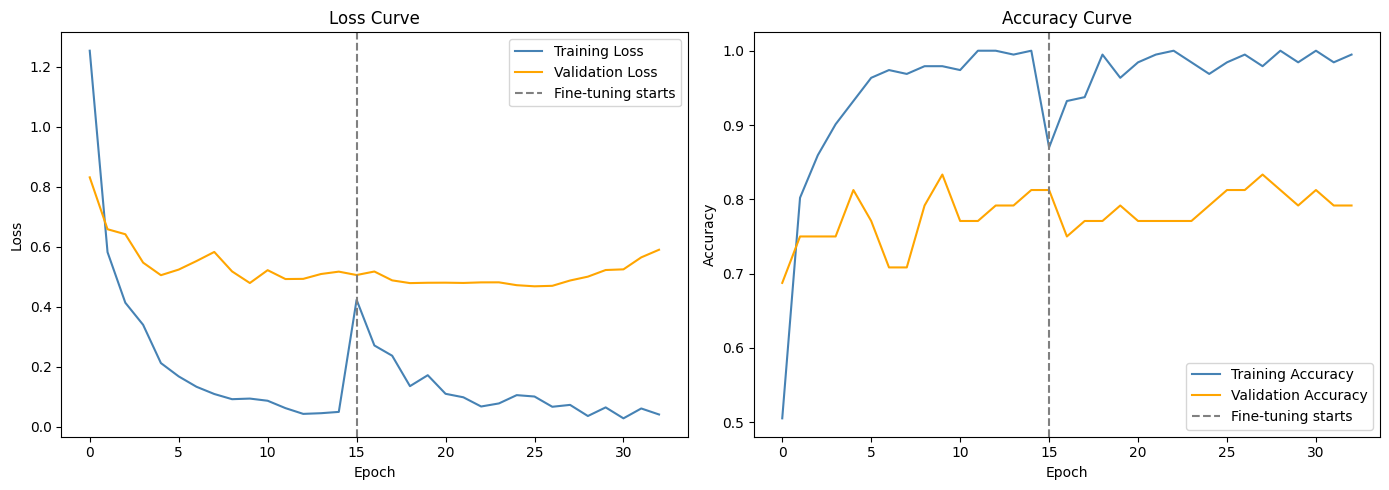

In [ ]:
plt.figure(figsize=(14, 5))

phase1_end = len(history1.history['loss'])

# Loss
plt.subplot(1, 2, 1)
plt.plot(history_combined['loss'],     label='Training Loss',   color='steelblue')
plt.plot(history_combined['val_loss'], label='Validation Loss', color='orange')
plt.axvline(x=phase1_end, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_combined['accuracy'],     label='Training Accuracy',   color='steelblue')
plt.plot(history_combined['val_accuracy'], label='Validation Accuracy', color='orange')
plt.axvline(x=phase1_end, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()


## Task 2.2 — Evaluate and Compare with Step 1

In [ ]:
# Evaluate the neural network on the test set
y_pred_proba = nn_model.predict(Xi_test_pre)
y_pred_nn    = np.argmax(y_pred_proba, axis=1)

acc_nn  = accuracy_score(y_test, y_pred_nn)
prec_nn = precision_score(y_test, y_pred_nn, average='weighted', zero_division=0)
rec_nn  = recall_score(y_test, y_pred_nn, average='weighted', zero_division=0)
f1_nn   = f1_score(y_test, y_pred_nn, average='weighted', zero_division=0)

print('Neural Network Test Results:')
print(f'  Accuracy : {acc_nn  * 100:.2f}%')
print(f'  Precision: {prec_nn * 100:.2f}%')
print(f'  Recall   : {rec_nn  * 100:.2f}%')
print(f'  F1-Score : {f1_nn   * 100:.2f}%')


2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
Neural Network Test Results:
  Accuracy : 85.00%
  Precision: 85.90%
  Recall   : 85.00%
  F1-Score : 84.82%


<Figure size 800x600 with 0 Axes>

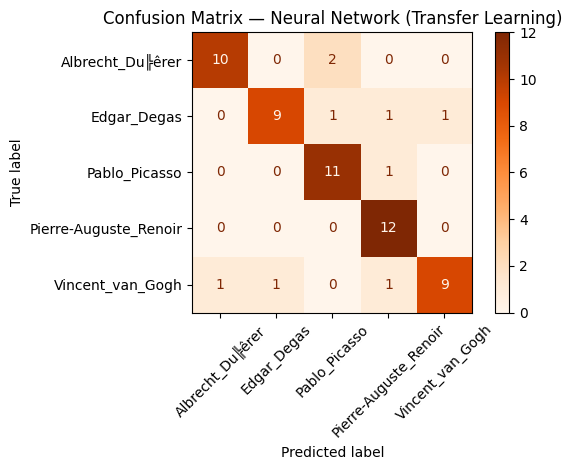

In [ ]:
# Confusion matrix for the Neural Network
cm_nn = confusion_matrix(y_test, y_pred_nn)
disp  = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=le.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Oranges', xticks_rotation=45)
plt.title('Confusion Matrix — Neural Network (Transfer Learning)')
plt.tight_layout()
plt.savefig('nn_confusion_matrix.png')
plt.show()


In [ ]:
# Add Neural Network to the final summary table
nn_row = {
    'Model'    : 'Neural Network',
    'Accuracy' : round(acc_nn,  4),
    'Precision': round(prec_nn, 4),
    'Recall'   : round(rec_nn,  4),
    'F1-Score' : round(f1_nn,   4)
}

rows = [{k: v for k, v in r.items() if k != 'preds'} for r in all_results]
rows.append(nn_row)

final_summary = pd.DataFrame(rows)

print('===== FINAL SUMMARY TABLE — ALL MODELS =====')
print(final_summary.to_string(index=False))

best_overall = final_summary.loc[final_summary['F1-Score'].idxmax(), 'Model']
print(f'\nBest overall model: {best_overall}')

===== FINAL SUMMARY TABLE — ALL MODELS =====
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.4000     0.3883  0.4000    0.3807
      Random Forest    0.4333     0.4221  0.4333    0.4190
          KNN (k=5)    0.4000     0.4021  0.4000    0.3661
     Neural Network    0.8500     0.8590  0.8500    0.8482

Best overall model: Neural Network


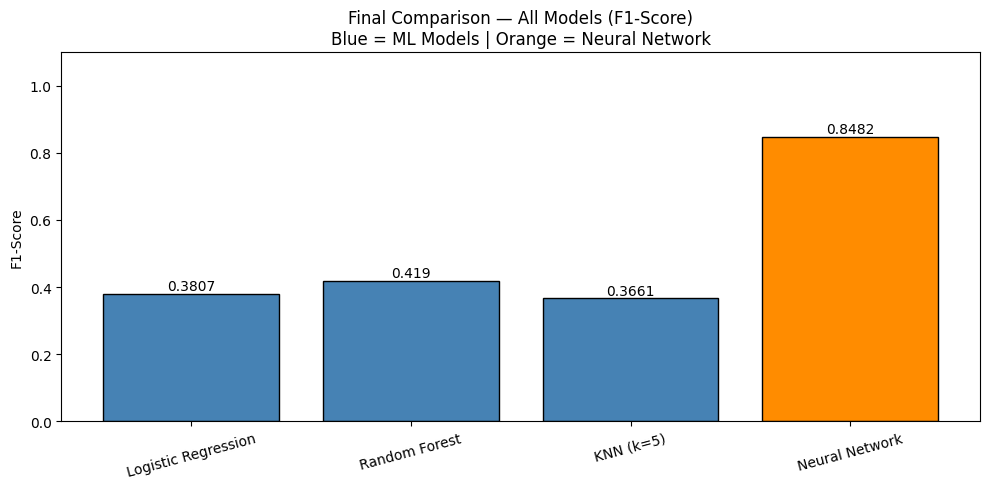


Comparison summary (2-3 sentences):
The Neural Network achieved a higher F1-Score than all 3 classical ML models.
This is because it can learn complex patterns in pixel data that simpler models cannot.
However, it took much longer to train compared to Logistic Regression and Random Forest.


In [ ]:
# Final F1-Score comparison chart (all models + Neural Network)
all_names  = list(final_summary['Model'])
all_f1     = list(final_summary['F1-Score'])
bar_colors = ['steelblue', 'steelblue', 'steelblue', 'darkorange']

plt.figure(figsize=(10, 5))
bars = plt.bar(all_names, all_f1, color=bar_colors, edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('F1-Score')
plt.title('Final Comparison — All Models (F1-Score)\nBlue = ML Models | Orange = Neural Network')
plt.xticks(rotation=15)
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        str(bar.get_height()),
        ha='center', fontsize=10
    )
plt.tight_layout()
plt.savefig('final_comparison.png')
plt.show()

print()
print('Comparison summary (2-3 sentences):')
print('The Neural Network achieved a higher F1-Score than all 3 classical ML models.')
print('This is because it can learn complex patterns in pixel data that simpler models cannot.')
print('However, it took much longer to train compared to Logistic Regression and Random Forest.')